# NAME - *Hitesh Girish Deore*
# ROLL NO - 2505

# Assignment:- 3


# Practical: 4 Random Sampling Techniques and Estimation

## a) Simple Random Sampling

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as ss
y=np.array([12,15,18,20,22,25,27,30,32,35,14,16,19,21,23,26,28,31,33,36,13,17,24,29,34,37,38,39,40,42])
N=len(y)

In [4]:
#ii)
pop_mean=np.mean(y)
pop_var=np.var(y,ddof=0)
print(f"population mean: {pop_mean:.4f} and population variance:{pop_var:.4f} ")

population mean: 26.5333 and population variance:75.9156 


In [5]:
#iii)
np.random.seed(123)
sample_wr=np.random.choice(y,8,replace=True)
sample_wr

array([21, 18, 40, 18, 27, 31, 36, 14])

In [6]:
#iv)
Ybar_wr=np.mean(sample_wr)
sig2_wr=np.var(sample_wr,ddof=1)
print(f"sample mean: {Ybar_wr:.4f} and sample variance:{sig2_wr:.4f} for with replacement")

sample mean: 25.6250 and sample variance:88.2679 for with replacement


In [7]:
#v)
np.random.seed(123)
sample_wor=np.random.choice(y,8,replace=False)
sample_wor

array([30, 42, 25, 38, 32, 39, 19, 17])

In [8]:
#vi)
Ybar_wor=np.mean(sample_wor)
sig2_wor=np.var(sample_wor,ddof=1)
print(f"sample mean: {Ybar_wor:.4f} and sample variance:{sig2_wor:.4f} for without replacement")

sample mean: 30.2500 and sample variance:86.7857 for without replacement


In [9]:
#vii)
VYbar_wr=[]
VYbar_wor=[]
for i in range(1000):
     VYbar_wr.append(np.mean(np.random.choice(y,8,replace=True)))
     VYbar_wor.append(np.mean(np.random.choice(y,8,replace=False)))
print(np.mean(VYbar_wr))
print(np.mean(VYbar_wor))          


26.644
26.44225


<Axes: ylabel='Density'>

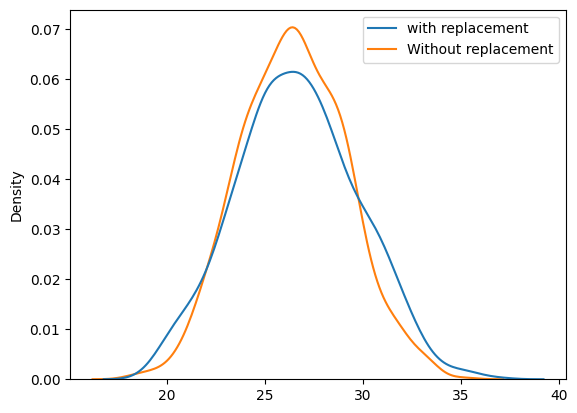

In [10]:
import seaborn as sns 
sns.kdeplot(pd.DataFrame({"with replacement":VYbar_wr,"Without replacement":VYbar_wor}))

In [38]:
#viii)
pd.DataFrame({"Method":["SRSWR","SRSWOR"],
     "Means":[np.mean(VYbar_wr),np.mean(VYbar_wor)],
      "Var":[np.var(VYbar_wr),np.var(VYbar_wor)],       
      "MSE": [np.mean((VYbar_wr-pop_mean)**2),np.mean((VYbar_wor-pop_mean)**2)]})

,Method,Means,Var,MSE
0,SRSWR,26.391375,9.650154,9.670306
1,SRSWOR,26.510375,7.789283,7.789810


## b) Stratified Random Sampling

In [5]:
#i) & ii)
Y1=np.array([10,12,14,15,16,18,20,22])
Y2=np.array([25,27,28,30,32,34,35,36])
Y3=np.array([40,42,45,47,48,50,52,55])
Y=np.concatenate([Y1,Y2,Y3])
N1,N2,N3=len(Y1),len(Y2),len(Y3)
N=len(Y)
true_mean=np.mean(Y)
print(true_mean)
np.random.seed(123)
n=6

n1_p = int(n * N1 / N)
n2_p = int(n * N2 / N)
n3_p = n - n1_p - n2_p   # adjust to sum to n

s1_p = np.random.choice(Y1, n1_p, replace=False)
s2_p = np.random.choice(Y2, n2_p, replace=False)
s3_p = np.random.choice(Y3, n3_p, replace=False)

print("Proportional samples:")
print(s1_p, s2_p, s3_p)
# Equal allocation
n1_e = n2_e = n3_e = n // 3

s1_e = np.random.choice(Y1, n1_e, replace=False)
s2_e = np.random.choice(Y2, n2_e, replace=False)
s3_e = np.random.choice(Y3, n3_e, replace=False)

print("Equal allocation samples:")
print(s1_e, s2_e, s3_e)
# Stratum weights
W1, W2, W3 = N1/N, N2/N, N3/N

# Sample means
ybar1_p = np.mean(s1_p)
ybar2_p = np.mean(s2_p)
ybar3_p = np.mean(s3_p)

#Stratified mean 
ybar_strat_p = W1*ybar1_p + W2*ybar2_p + W3*ybar3_p

print("Stratified Mean (Proportional):", ybar_strat_p)
s1_sq = np.var(s1_p, ddof=1)
s2_sq = np.var(s2_p, ddof=1)
s3_sq = np.var(s3_p, ddof=1)

var_strat = (
    W1**2 * (1 - n1_p/N1) * s1_sq / n1_p +
    W2**2 * (1 - n2_p/N2) * s2_sq / n2_p +
    W3**2 * (1 - n3_p/N3) * s3_sq / n3_p
)
print("Variance of Stratified Mean:", var_strat)
srs_sample = np.random.choice(Y, n, replace=False)
ybar_srs = np.mean(srs_sample)
srs_var = (1 - n/N) * np.var(srs_sample, ddof=1) / n

print("SRS Mean:", ybar_srs)
print("SRS Variance:", srs_var)
gain = srs_var / var_strat
print("Gain in Precision (SRS / Stratified):", gain)

31.375
Proportional samples:
[10 12] [34 25] [47 50]
Equal allocation samples:
[22 14] [36 25] [48 45]
Stratified Mean (Proportional): 29.666666666666664
Variance of Stratified Mean: 1.9583333333333333
SRS Mean: 34.5
SRS Variance: 10.6375
Gain in Precision (SRS / Stratified): 5.431914893617021


## c) Cluster Random Sampling

In [6]:
#Clusters (each of size K = 5)
clusters = [
    np.array([10, 11, 12, 13, 14]),
    np.array([15, 16, 17, 18, 19]),
    np.array([20, 21, 22, 23, 24]),
    np.array([30, 31, 32, 33, 34]),
    np.array([35, 36, 37, 38, 39]),
    np.array([40, 41, 42, 43, 44])
]
M = len(clusters)      
K = len(clusters[0])   
N = M * K              
population = np.concatenate(clusters)
true_mean = np.mean(population)
print("True Population Mean:", true_mean)
np.random.seed(1)
m = 2
selected_idx = np.random.choice(M, size=m, replace=False)
selected_clusters = [clusters[i] for i in selected_idx]
print("Selected cluster indices:", selected_idx)

True Population Mean: 27.0
Selected cluster indices: [2 1]


# Practical 5: Monte Carlo Simulation for Statistical Properties.

In [7]:
## a) Bias and Meam Squared Error of Estimators

In [8]:
B,n=1000,30
mu,sigma=100,10
alpha=0.05
Xbar=[]
Sigma2=[]
LCL=[]
UCL=[]

In [11]:
z_alpha2=ss.norm.ppf(1-alpha/2)
print(z_alpha2)

1.959963984540054


In [12]:
for _ in range(B):
    s0=np.random.normal(mu,sigma,n)
    Xbar.append(np.mean(s0))
    Sigma2.append(np.var(s0,ddof=1))

LCL=Xbar-z_alpha2*np.sqrt(Sigma2)/np.sqrt(n)
UCL=Xbar+z_alpha2*np.sqrt(Sigma2)/np.sqrt(n)
df=pd.DataFrame({"Xbar":Xbar,"Sigma2":Sigma2,"Lower":LCL,"Upper":UCL,"MeanInCI":(LCL<mu)&(mu<UCL)})
sum(df.MeanInCI)

942

<Axes: ylabel='Density'>

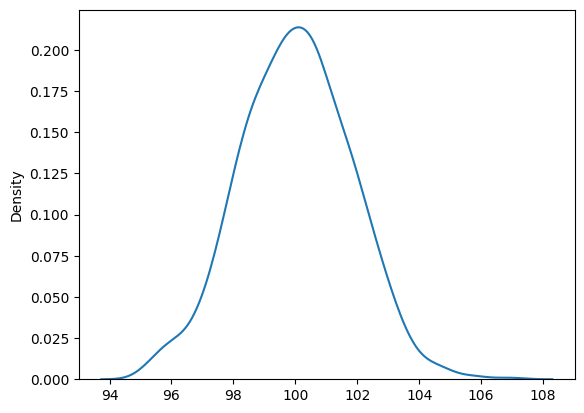

In [13]:
sns.kdeplot(Xbar)

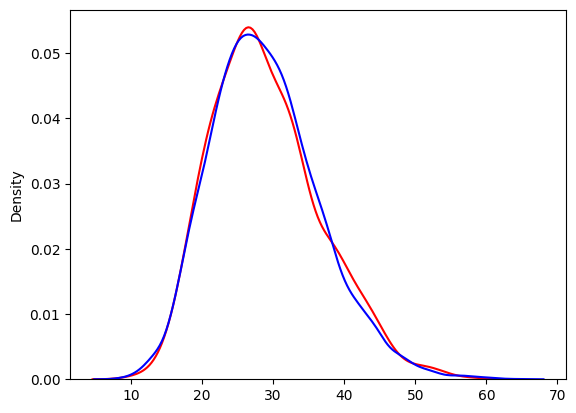

In [14]:
sns.kdeplot((n-1)*np.array(Sigma2)/(sigma**2),color="Red")
sns.kdeplot(np.random.chisquare(n-1,10000),color="Blue")
plt.show()

In [15]:
p=0.5
B,n=10000,30
phat=[]
LCL=[]
UCL=[]
Var_phat=[]
for _ in range(B):
    s1=np.random.binomial(1,p,n)
    P_hat=np.mean(s1)  
    phat.append(P_hat)
    Var_phat= (P_hat*(1-np.array(P_hat)/np.float64(n)))   
    LCL=P_hat-z_alpha2*np.sqrt(Var_phat)
    UCL=P_hat+z_alpha2*np.sqrt(Var_phat)
df=pd.DataFrame({"phat":phat,"Lower":LCL,"Upper":UCL,"PInCI":(LCL<p)&(p<UCL)})
np.mean(df.PInCI)

np.float64(1.0)

<Axes: ylabel='Density'>

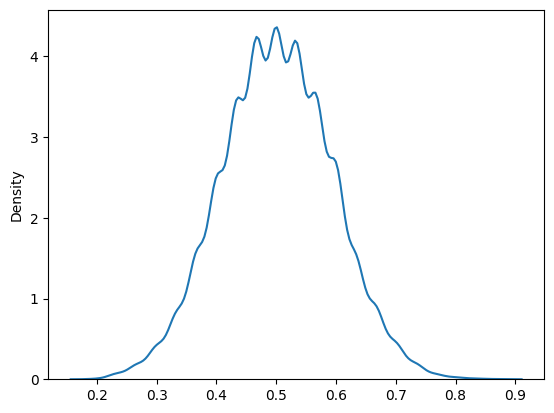

In [16]:
sns.kdeplot(phat)

## b) Power Curve of a Hypothesis Test

<class 'pandas.core.frame.DataFrame'>
(40, 3)
Index(['Sample size (n)', 'Difference (μ − μ0)', 'Power'], dtype='object')
Index(['n', 'Difference', 'Power'], dtype='object')


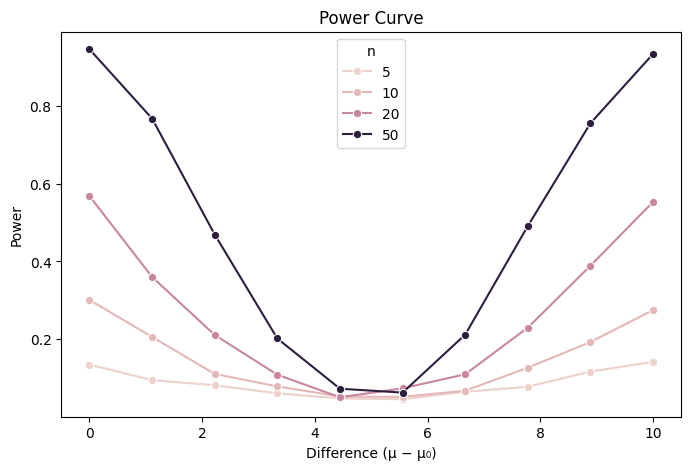

In [21]:
B = 1000
mu0 = 105
mu = 100
sigma = 10
alpha = 0.05

diff = np.linspace(0, 10, 10)
n_values = [5, 10, 20,50]   # different sample sizes
results = []

for n in n_values:
    for j in diff:
        Decision = []
        for _ in range(B):
            sample = np.random.normal(mu + j, sigma, n)
            t_stat, pval = ss.ttest_1samp(sample, mu0)
            Decision.append(pval < alpha)
        
        power_val = np.mean(Decision)
        results.append({
            'Sample size (n)': n,
            'Difference (μ − μ0)': j,
            'Power': power_val
        })
df = pd.DataFrame(results)
print(type(df))
print(df.shape)
print(df.columns)
df.head()
df.columns = ['n', 'Difference', 'Power']
print(df.columns)
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df,
    x='Difference',
    y='Power',
    hue='n',
    marker='o'
)
plt.xlabel('Difference (μ − μ₀)')
plt.ylabel('Power')
plt.title('Power Curve')
plt.show()

## c) Type 1 Error Under Assumption Violations 

In [20]:
mu,sig=100,10
b,n=1000,30
alpha=0.05
scale=1
rejection_normal=[]
rejection_exp=[]
rejection_cauchy=[]
for _ in range(B):
    t_stat,p_value=ss.ttest_1samp(np.random.normal(mu,sigma,n),100)
    rejection_normal.append(p_value<alpha)
    type1_normal = np.mean(rejection_normal)

    t_stat,p_value=ss.ttest_1samp(np.random.exponential(scale,n),100)
    rejection_exp.append(p_value<alpha)
    type1_exp = np.mean(rejection_exp)

    t_stat,p_value=ss.ttest_1samp(ss.cauchy.rvs(mu,scale,n),100)
    rejection_cauchy.append(p_value<alpha)
    type1_cauchy = np.mean(rejection_cauchy)

result = pd.DataFrame({
    "Distribution": ["Normal", "Exponential", "Cauchy"],
    "Empirical Type I Error": [type1_normal, type1_exp, type1_cauchy]
})

result

,Distribution,Empirical Type I Error
0,Normal,0.047
1,Exponential,1.000
2,Cauchy,0.029


## Comment:
The t-test is robust to mild departures from normality, especially for moderate sample sizes.
However, it is not robust under severe non-normality such as heavy-tailed (Cauchy) distributions.